## Cluster-Mass based Permutation testing in Julia

- Step 1: load and check adjacency matrix
- Step 2: fit model on data
- Step 3: run cluster-mass permutation test
- Step 4: plotting

In [1]:
import Pkg
#Pkg.activate("/data/p_02865/tools/UnfoldStats.jl/docs")
Pkg.activate("..")
Pkg.instantiate()


#using UnfoldSim
using MAT
using CairoMakie
using Random
using Statistics
#using UnfoldMixedModels
#using UnfoldStats
using DataFrames
#using MixedModelsPermutations
using UnfoldMakie
using Logging
#using ClusterDepth
using CSV
using GLM
using LinearAlgebra
using Random
using AnovaGLM
using Distributions
using StatsModels

#ext = Base.get_extension(UnfoldStats, :UnfoldStatsMixedModelsPermutationsExt)
#lmm_permutations = ext.lmm_permutations
#get_lmm_statistic = ext.get_lmm_statistic


#include("../read_adjacency.jl")
include("../cluster_mass_test.jl")


  Activating project at `~/Desktop/ClusterComputation`
Precompiling project...
   1702.8 ms  ✓ Effects
   1805.4 ms  ✓ GLM
   2028.6 ms  ✓ Effects → EffectsGLMExt
  21924.4 ms  ✓ AlgebraOfGraphics
  29049.5 ms  ✓ MixedModels
   7903.5 ms  ✓ AlgebraOfGraphics → AlgebraOfGraphicsUnitfulExt
  27854.1 ms  ✓ Unfold
   4475.7 ms  ✓ Effects → EffectsMixedModelsExt
   4481.3 ms  ✓ MixedModels → MixedModelsForwardDiffExt
   5747.2 ms  ✓ Unfold → UnfoldBSplineKitExt
   3804.9 ms  ✓ MixedModelsPermutations
   3923.5 ms  ✓ MixedModelsSim
   5146.3 ms  ✓ UnfoldStats
   6693.2 ms  ✓ UnfoldMixedModels
   7753.9 ms  ✓ UnfoldSim
   6415.6 ms  ✓ UnfoldStats → UnfoldStatsMixedModelsExt
  14328.9 ms  ✓ UnfoldMakie
   6628.0 ms  ✓ UnfoldStats → UnfoldStatsMixedModelsPermutationsExt
  13519.0 ms  ✓ UnfoldMakie → UnfoldMakieUnfoldSimExt
  17320.3 ms  ✓ UnfoldMakie → UnfoldMakiePyMNEExt
  20 dependencies successfully precompiled in 71 seconds. 532 already precompiled.
  2 dependencies had output during precom

spatiotemporal_cluster_pvalues (generic function with 1 method)

In [2]:
# 1. Positions CSV
positions_df = CSV.read("channel_positions_Magda.csv", DataFrame;
                     types=[String, Float64, Float64])

# 2.adjacency CSV
adj_df = CSV.read("adjacency_Magda.csv", DataFrame; stringtype=String, strict=false)
electrode_labels = adj_df.Column1
adjacency = select!(adj_df, Not(1))
adjacency = Matrix(adjacency)
adjacency = Bool.(adjacency)

59×59 BitMatrix:
 1  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  1  1  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0  0     1  0  0  0  0  0  0  1  1  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0  0     0  0  0  0  0  1  0  0  0  0  0  1
 0  0  0  0  0  0  0  0  0  1  0  0  0     0  0  0  0  0  0  1  0  0  0  0  1
 ⋮              ⋮              ⋮        ⋱           ⋮              ⋮        
 0  0  0  0  0  0  0  0  0  0  0  0  1  …  0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0 

## 1. Correctly format the EEG data
- **60 subjects** (20 per group)
- **3 time points**
- **3 dependent variables** 1/f, alpha and beta (should all be in seperate data arrays)

In [3]:
electrode_labels

59-element Vector{String}:
 "Fp1"
 "Fp2"
 "F3"
 "F4"
 "C3"
 "C4"
 "P3"
 "P4"
 "O1"
 "O2"
 ⋮
 "TP7"
 "TP8"
 "PO7"
 "PO8"
 "Fpz"
 "AFz"
 "FCz"
 "CPz"
 "POz"

In [4]:
# read the data
#dfs = DataFrame
df = CSV.read("/Users/mg/Desktop/MOVE/resting_state/fooof/Fp1_fooof_params.csv", DataFrame)
df = filter(row -> row[:time] == 1, df)  # only keep RS1
df[! ,:channel] = repeat(["Fp1"], nrow(df))
for n in names(df)
    if eltype(df[!, n]) <: Union{Missing, Float64}
        df[!, n] = coalesce.(df[!, n], NaN)
    end
end

for (i, channel) in enumerate(electrode_labels)
    df_fooof = CSV.read("/Users/mg/Desktop/MOVE/resting_state/fooof/$(channel)_fooof_params.csv", DataFrame)
    df_fooof = filter(row -> row[:time] == 1, df_fooof)  # only keep RS1
    df_fooof[! ,:channel] = repeat([channel], nrow(df_fooof))

    for n in names(df_fooof)
        if eltype(df_fooof[!, n]) <: Union{Missing, Float64}
            df_fooof[!, n] = coalesce.(df_fooof[!, n], NaN)
        end
    end

    #print(i)
    if i == 1
        print("skip first channel Fp1, because already in the df")
    #elseif i == 52  # channel TP8 has "missing" values, replace with nan
        #println("52")
        #println(channel)
     #   for n in names(df_fooof)
      #      if eltype(df_fooof[!, n]) <: Union{Missing, Float64}
       #         df_fooof[!, n] = coalesce.(df_fooof[!, n], NaN)
       #     end
       # end
        #print(df_fooof)
        #append!(df, df_fooof)
    else
        append!(df, df_fooof)
    end

end



skip first channel Fp1, because already in the df

In [5]:
df

Row,Column1,subject,time,error,r_squared,exponent,offset,alpha_CF,alpha_PW,alpha_BW,beta_CF,beta_PW,beta_BW,alpha_PW_absolute_periodic,beta_PW_absolute_periodic,alpha_PW_absolute_total,beta_PW_absolute_total,alpha_PW_relative,beta_PW_relative,alpha_PW_absolute_periodic_log,beta_PW_absolute_periodic_log,alpha_PW_absolute_total_log,beta_PW_absolute_total_log,alpha_PW_absolute_total_2,beta_PW_absolute_total_2,alpha_PW_absolute_total_2_log,beta_PW_absolute_total_2_log,channel
,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String
1,0,1,1,0.0120474,0.995045,0.836004,-11.6986,10.8954,0.162103,0.5,17.7063,0.137714,0.830118,1.06737e-13,5.75031e-14,3.84868e-13,2.40876e-13,0.277333,0.238725,-12.9717,-13.2403,-12.4147,-12.6182,3.98471e-13,2.40876e-13,-12.3996,-12.6182,Fp1
2,3,2,1,0.0318237,0.980819,0.913947,-11.6218,NaN,NaN,NaN,20.9886,0.229849,5.42677,1.30757e-13,1.11931e-13,4.96164e-13,2.58476e-13,0.263537,0.433042,-12.8835,-12.951,-12.3044,-12.5876,4.96164e-13,2.58476e-13,-12.3044,-12.5876,Fp1
3,6,3,1,0.0377277,0.982479,0.761139,-11.8092,10.2882,1.10372,1.54147,24.8643,0.378764,7.84135,2.76727e-12,2.16736e-13,3.03816e-12,3.57604e-13,0.910837,0.606078,-11.5579,-12.6641,-11.5174,-12.4466,3.03816e-12,3.57604e-13,-11.5174,-12.4466,Fp1
4,9,5,1,0.0327592,0.989902,1.44757,-10.9281,11.9415,0.452768,1.89097,19.3777,0.242538,6.5182,5.65797e-13,1.42783e-13,9.01375e-13,3.05651e-13,0.627704,0.467145,-12.2473,-12.8453,-12.0451,-12.5148,9.01375e-13,3.62333e-13,-12.0451,-12.4409,Fp1
5,12,6,1,0.022545,0.996043,1.51886,-10.7828,10.7454,0.245514,1.00614,18.3373,0.292934,6.74521,4.09459e-13,2.03554e-13,1.12317e-12,4.04612e-13,0.364558,0.503085,-12.3878,-12.6913,-11.9496,-12.393,1.12317e-12,4.43298e-13,-11.9496,-12.3533,Fp1
6,15,8,1,0.023285,0.986889,0.984632,-11.9953,11.1497,0.570406,1.28093,19.934,0.221327,2.67899,2.07887e-13,3.60267e-14,3.00701e-13,8.94983e-14,0.691342,0.40254,-12.6822,-13.4434,-12.5219,-13.0482,3.00701e-13,9.57862e-14,-12.5219,-13.0187,Fp1
7,18,9,1,0.0164544,0.998164,1.5271,-10.9204,11.0095,0.451856,1.91732,23.101,0.0555912,0.636283,5.53514e-13,1.27745e-13,8.68663e-13,3.23145e-13,0.637202,0.395318,-12.2569,-12.8937,-12.0611,-12.4906,8.68663e-13,3.23145e-13,-12.0611,-12.4906,Fp1
8,21,10,1,0.0399623,0.975672,0.780525,-11.4595,10.4742,1.21852,1.26784,20.4271,0.231088,5.38538,6.74184e-12,2.64595e-13,7.30382e-12,5.92366e-13,0.923057,0.446675,-11.1712,-12.5774,-11.1364,-12.2274,7.30382e-12,5.92366e-13,-11.1364,-12.2274,Fp1
9,24,11,1,0.055915,0.979295,1.38157,-10.9737,11.0329,1.18064,1.51931,20.9341,0.418561,5.67423,4.83074e-12,3.22631e-13,5.24201e-12,5.18603e-13,0.921544,0.622114,-11.316,-12.4913,-11.2805,-12.2852,5.24201e-12,5.18603e-13,-11.2805,-12.2852,Fp1


In [6]:
# format the independent variables for the mixed models
df_behavior = CSV.read("/Users/mg/Desktop/MOVE/MOVE_Analysis_MG/KINARM/behavioral_measure.csv", DataFrame)
rename!(df_behavior, :VP => :subject )
df_evts = select(df_behavior, [:subject, :Behavior, :Group])
evts = repeat(df_evts, inner = 3)
evts.Time = repeat(1:3, 60)
#evts.subject = string.(evts.subject)  # Subject needs to be categorical for model
evts
evts = filter(row -> row[:Time] == 1, evts)



Row,subject,Behavior,Group,Time
,Int64,Float64,String1,Int64
1,1,0.0623471,C,1
2,2,-6.97687,A,1
3,3,-2.00111,M,1
4,5,-3.37025,M,1
5,6,-8.1817,A,1
6,8,-0.929943,C,1
7,9,-2.71605,M,1
8,10,-7.5614,A,1
9,11,-8.42534,A,1


In [7]:
df_model = innerjoin(df, evts, on = :subject)
df_model.subject = string.(df_model.subject)  # Subject needs to be categorical for model
df_model

Row,Column1,subject,time,error,r_squared,exponent,offset,alpha_CF,alpha_PW,alpha_BW,beta_CF,beta_PW,beta_BW,alpha_PW_absolute_periodic,beta_PW_absolute_periodic,alpha_PW_absolute_total,beta_PW_absolute_total,alpha_PW_relative,beta_PW_relative,alpha_PW_absolute_periodic_log,beta_PW_absolute_periodic_log,alpha_PW_absolute_total_log,beta_PW_absolute_total_log,alpha_PW_absolute_total_2,beta_PW_absolute_total_2,alpha_PW_absolute_total_2_log,beta_PW_absolute_total_2_log,channel,Behavior,Group,Time
,Int64,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Float64,String1,Int64
1,0,1,1,0.0120474,0.995045,0.836004,-11.6986,10.8954,0.162103,0.5,17.7063,0.137714,0.830118,1.06737e-13,5.75031e-14,3.84868e-13,2.40876e-13,0.277333,0.238725,-12.9717,-13.2403,-12.4147,-12.6182,3.98471e-13,2.40876e-13,-12.3996,-12.6182,Fp1,0.0623471,C,1
2,3,2,1,0.0318237,0.980819,0.913947,-11.6218,NaN,NaN,NaN,20.9886,0.229849,5.42677,1.30757e-13,1.11931e-13,4.96164e-13,2.58476e-13,0.263537,0.433042,-12.8835,-12.951,-12.3044,-12.5876,4.96164e-13,2.58476e-13,-12.3044,-12.5876,Fp1,-6.97687,A,1
3,6,3,1,0.0377277,0.982479,0.761139,-11.8092,10.2882,1.10372,1.54147,24.8643,0.378764,7.84135,2.76727e-12,2.16736e-13,3.03816e-12,3.57604e-13,0.910837,0.606078,-11.5579,-12.6641,-11.5174,-12.4466,3.03816e-12,3.57604e-13,-11.5174,-12.4466,Fp1,-2.00111,M,1
4,9,5,1,0.0327592,0.989902,1.44757,-10.9281,11.9415,0.452768,1.89097,19.3777,0.242538,6.5182,5.65797e-13,1.42783e-13,9.01375e-13,3.05651e-13,0.627704,0.467145,-12.2473,-12.8453,-12.0451,-12.5148,9.01375e-13,3.62333e-13,-12.0451,-12.4409,Fp1,-3.37025,M,1
5,12,6,1,0.022545,0.996043,1.51886,-10.7828,10.7454,0.245514,1.00614,18.3373,0.292934,6.74521,4.09459e-13,2.03554e-13,1.12317e-12,4.04612e-13,0.364558,0.503085,-12.3878,-12.6913,-11.9496,-12.393,1.12317e-12,4.43298e-13,-11.9496,-12.3533,Fp1,-8.1817,A,1
6,15,8,1,0.023285,0.986889,0.984632,-11.9953,11.1497,0.570406,1.28093,19.934,0.221327,2.67899,2.07887e-13,3.60267e-14,3.00701e-13,8.94983e-14,0.691342,0.40254,-12.6822,-13.4434,-12.5219,-13.0482,3.00701e-13,9.57862e-14,-12.5219,-13.0187,Fp1,-0.929943,C,1
7,18,9,1,0.0164544,0.998164,1.5271,-10.9204,11.0095,0.451856,1.91732,23.101,0.0555912,0.636283,5.53514e-13,1.27745e-13,8.68663e-13,3.23145e-13,0.637202,0.395318,-12.2569,-12.8937,-12.0611,-12.4906,8.68663e-13,3.23145e-13,-12.0611,-12.4906,Fp1,-2.71605,M,1
8,21,10,1,0.0399623,0.975672,0.780525,-11.4595,10.4742,1.21852,1.26784,20.4271,0.231088,5.38538,6.74184e-12,2.64595e-13,7.30382e-12,5.92366e-13,0.923057,0.446675,-11.1712,-12.5774,-11.1364,-12.2274,7.30382e-12,5.92366e-13,-11.1364,-12.2274,Fp1,-7.5614,A,1
9,24,11,1,0.055915,0.979295,1.38157,-10.9737,11.0329,1.18064,1.51931,20.9341,0.418561,5.67423,4.83074e-12,3.22631e-13,5.24201e-12,5.18603e-13,0.921544,0.622114,-11.316,-12.4913,-11.2805,-12.2852,5.24201e-12,5.18603e-13,-11.2805,-12.2852,Fp1,-8.42534,A,1


In [31]:
# replace nan to missing
df_model[!, :alpha_PW_absolute_periodic_log] =
    (x -> (isa(x, Real) && isnan(x) ? missing : x)).(df_model[!, :alpha_PW_absolute_periodic_log])

print(df_model[df_model.:channel .== "TP8", :].alpha_PW_absolute_periodic_log)


Union{Missing, Float64}[-12.622687842538356, -13.034829185821472, -11.330250202944478, -12.013092752566076, -12.241332258439947, -11.993433171200767, -12.024794066145828, -11.435439960314776, -11.342456482788327, -12.146889914349064, -11.918652540371026, -11.830551316606705, -11.927233059425006, -11.92993062759438, -11.888221096474036, -11.822533222994686, -11.601390288637305, missing, -12.457153136034496, -11.713682612204734, -11.560918792229254, -11.371407454054518, -12.57051780613916, -11.431634999606144, -12.541677728571694, -11.416655357595463, -11.320386075288766, -11.542527904995094, -12.589881949765742, -11.13273210966349, -11.11759068307387, -12.25579051300459, -12.407363747135841, -10.981510253557097, -11.54562238295257, -12.486901627277524, -12.522060984381104, -11.579648329719074, -11.123849451618819, -10.308690883867502, -10.924501031139998, -11.50765130756554, -11.224120282469647, -11.963936570728459, -12.956365338761849, -10.742147678959679, -11.439016160123579, -11.6618

## 2. fit model

In [82]:
# prepare results df
df_result = DataFrame(channel=String[], channel_number=Integer[], coefname=String[], F=Float64[], p=Float64[])

Row,channel,channel_number,coefname,F,p
,String,Integer,String,Float64,Float64


In [83]:
# set contrast to effectsCoding for Group to compare against mean
contr = Dict(
   :Group => EffectsCoding(base="C", levels=["A", "C", "M"]) # for ANOVA output, base does not matter in EffectsCoding; EffectsCoding compares to the mean
   #:Group => DummyCoding(base="M")
 )

println("Fitting LM at each channel...")

#for predictor in ["exponent", "alpha_PW_absolute_periodic_log", "beta_PW_absolute_periodic_log"]

channel_number = 1

for i in unique(df_model.channel)
    #println(i)


    subdf = df_model[df_model.:channel .== i, :]

    #m1 = lm(@formula(Behavior ~ Group * exponent), subdf; contrasts=contr)

    m1 = lm(@formula(Behavior ~ Group * alpha_PW_absolute_periodic_log), subdf; contrasts=contr)


    anova_result = anova(m1, type = 3)

    #print(m1)
    #print(anova_result)

    push!(df_result, (i, channel_number, "EEG", anova_result.teststat[3], anova_result.pval[3]))   # coef order: intercept, Group, EEG variable, Group & EEG variable
    #push!(df_result, (i, channel_number, "Interaction_Group_EEG", anova_result.teststat[4], anova_result.pval[4]))

    channel_number += 1

end

#end

Fitting LM at each channel...


In [60]:
print(df_result)

59×5 DataFrame
 Row │ channel  channel_number  coefname  F          p         
     │ String   Integer         String    Float64    Float64   
─────┼─────────────────────────────────────────────────────────
   1 │ Fp1                   1  EEG       0.534306   0.467962
   2 │ Fp2                   2  EEG       0.916823   0.342578
   3 │ F3                    3  EEG       0.335856   0.564641
   4 │ F4                    4  EEG       0.488589   0.487557
   5 │ C3                    5  EEG       4.19538    0.045409
   6 │ C4                    6  EEG       3.01013    0.0884502
   7 │ P3                    7  EEG       2.86004    0.0965697
   8 │ P4                    8  EEG       0.75498    0.38875
   9 │ O1                    9  EEG       0.511835   0.477428
  10 │ O2                   10  EEG       0.0623538  0.803761
  11 │ F7                   11  EEG       0.189569   0.665011
  12 │ F8                   12  EEG       1.04899    0.310307
  13 │ T7                   13  EEG       0.4710

In [67]:
# for testing/coding only

contr = Dict(
   :Group => EffectsCoding(base="C", levels=["A", "C", "M"]) # for ANOVA output, base does not matter in EffectsCoding; EffectsCoding compares to the mean
   #:Group => DummyCoding(base="M")
 )

subdf = df_model[df_model.:channel .== "C3", :]

m1 = lm(@formula(Behavior ~ Group * alpha_PW_absolute_periodic_log), subdf; contrasts=contr)

anova_result = anova(m1, type = 3)

    #print(m1)
print(anova_result)

Analysis of Variance

Type 3 test / F test

Behavior ~ 1 + Group + alpha_PW_absolute_periodic_log + Group & alpha_PW_absolute_periodic_log

Table:
────────────────────────────────────────────────────────────────────────────────────
                                        DOF   Exp.SS  Mean Square  F value  Pr(>|F|)
────────────────────────────────────────────────────────────────────────────────────
(Intercept)                               1  10.92        10.92    12.9155    0.0007
Group                                     2   6.9329       3.4664   4.1001    0.0220
alpha_PW_absolute_periodic_log            1   3.5470       3.5470   4.1954    0.0454
Group & alpha_PW_absolute_periodic_log    2   4.8666       2.4333   2.8781    0.0649
(Residuals)                              54  45.65         0.8454             
────────────────────────────────────────────────────────────────────────────────────

In [21]:
# for testing/coding only
fieldnames(typeof(anova_result))

(:anovamodel, :dof, :deviance, :teststat, :pval, :otherstat)

In [23]:
Y = predict(m1)

60-element Vector{Float64}:
 -0.5096106035450186
 -6.814507366431021
 -3.703190360630517
 -3.681974624008649
 -6.896646686159921
 -0.49210059020030184
 -3.200607829560545
 -7.2073726221041055
 -7.25875852941282
 -0.48697091051837926
  ⋮
 -0.5060103221537136
 -0.48931234679882846
 -6.9840701593879
 -6.840046134973303
 -2.034386969974044
 -3.409446569670913
 -3.2547728159711204
 -0.5110897135013159
 -3.448590512186608

In [ ]:
# nach hier mixed model code

Unique channels: 59


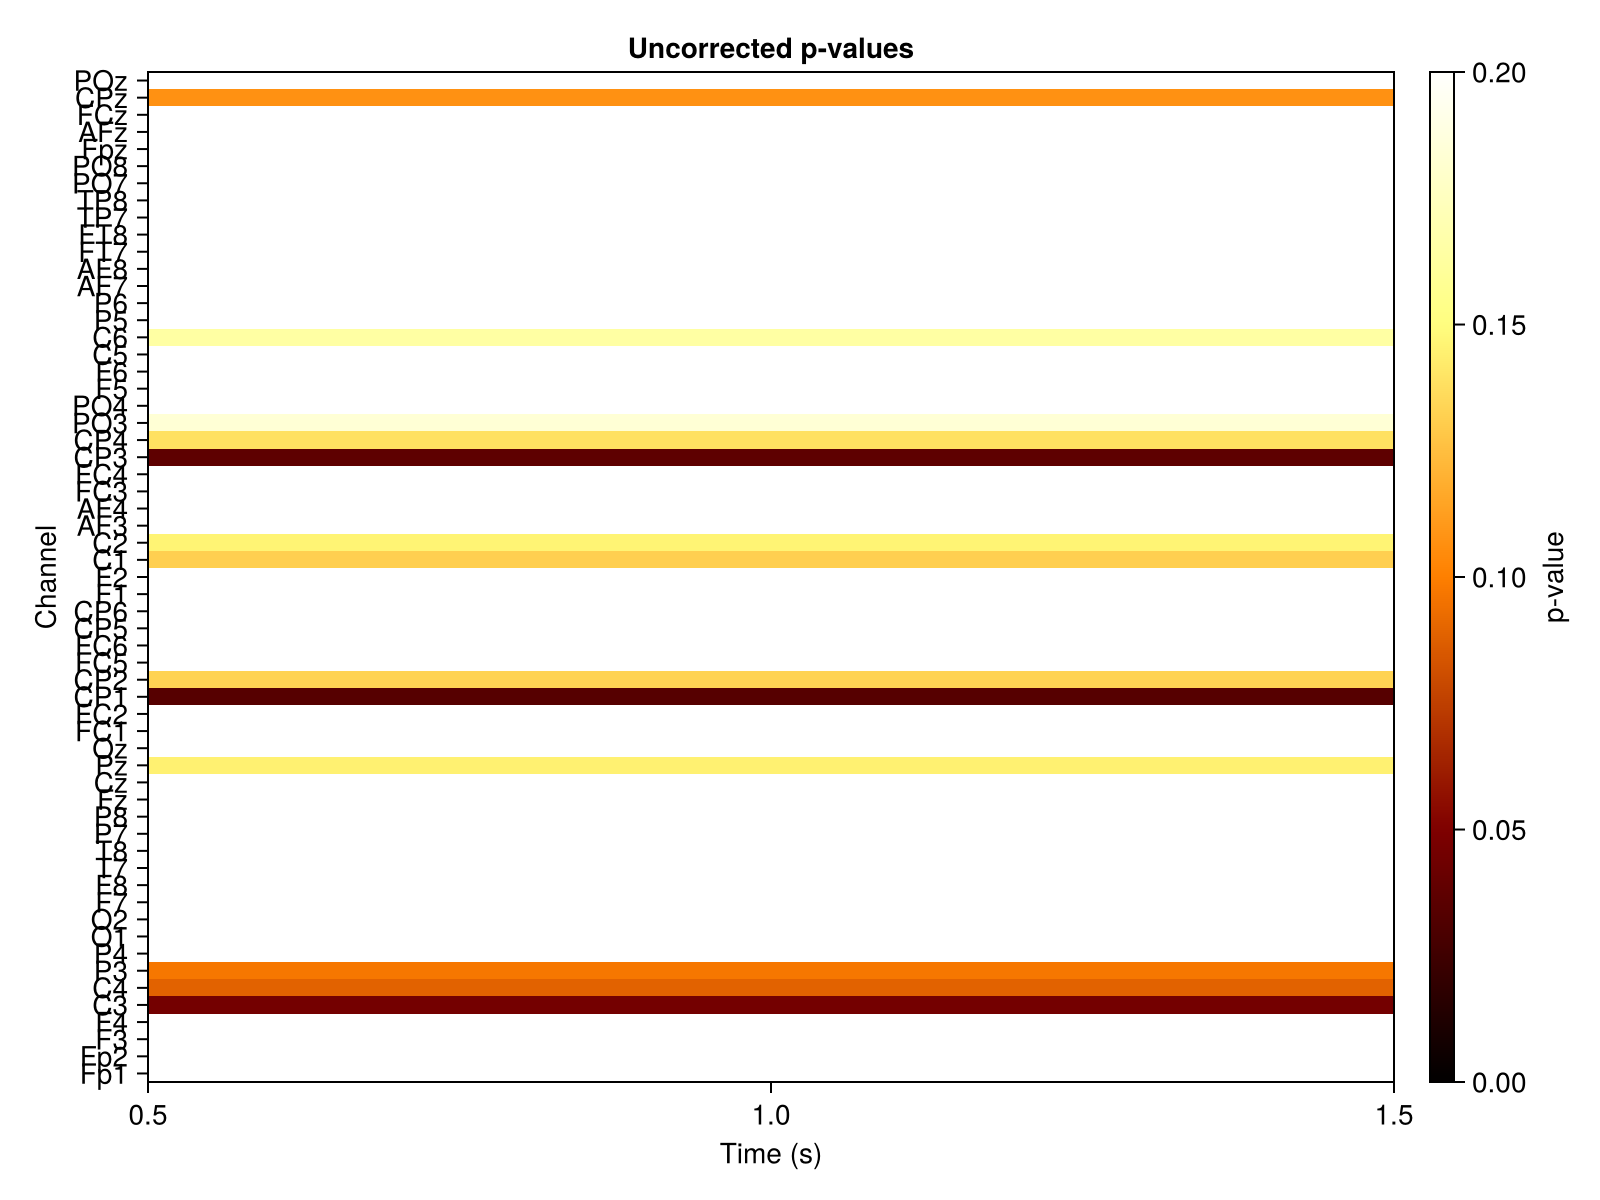

In [84]:
# Check uncorrected effects before running permutation test

# Filter for coefficient
#coef_stimtype = filter(r -> r.coefname == coefficient_name, coefs)
#println("Rows for stimtype: $(nrow(coef_stimtype))")

# Check how many unique channels and times we have
#unique_channels = sort(unique(coef_stimtype.channel))
unique_times = sort(unique(df_result.coefname))
println("Unique channels: $(nrow(df_result))")
#println("Unique times: $(length(unique_times))")

# Compute z-values from estimate/stderror, handling missing values
# Replace Nothing with NaN for computation
#estimate_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.estimate] # estimate same as z
#stderror_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.stderror]
#z_vec = estimate_vec #./ stderror_vec

#coef_stimtype[!, :z] = z_vec

# Average across groups if there are multiple entries per channel×time
#z_summary = combine(
#    groupby(coef_stimtype, [:channel, :time]),
#    :z => (x -> mean(filter(!isnan, x))) => :z
#)
#sort!(z_summary, [:channel, :time])

n_ch_coef = nrow(df_result)
# Replace NaN with 0 for visualization
#z_summary.z = replace(z_summary.z, NaN => 0.0)
#z_vals = df_result.F
#z_mat = reshape(z_vals, :, 1)
z_mat = reshape(df_result.p, 1, n_ch_coef)
z_mat = replace(z_mat, NaN=>0.0)
xs = 1:size(z_mat, 2)   #times
ys = 1:size(z_mat, 1)   # channels

# Reshape z-values to channels × times

#n_t_coef = length(unique_times)
#z_vals = reshape(z_summary.z, n_t_coef, n_ch_coef)'  # (channels × times)

# Check for significant z-values (|z| > 1.96)
#n_sig_uncorrected = sum(abs.(z_vals) .> 1.96)  # Paul used 2.0 here
#max_z = maximum(abs.(z_vals))
#peak_idx = argmax(abs.(z_vals))
#peak_ch, peak_t = Tuple(CartesianIndices(z_vals)[peak_idx])

#println("\n=== Uncorrected Effects (before permutation) ===")
#println("Max |z|: $(round(max_z, digits=2))")
#println("Peak location: channel $(electrode_labels[peak_ch]) at t = $(round(unique_times[peak_t], digits=3))s")
#println("Samples with |z| > 2.0: $(n_sig_uncorrected) / $(length(z_vals))")
#println("Samples with |z| > 1.96: $(sum(abs.(z_vals) .> 1.96)) (uncorrected p < 0.05)")

# Quick visualization of F-values
fig_z = Figure(size = (800, 600))
ax_z = Axis(fig_z[1, 1],
    title = "Uncorrected p-values",
    xlabel = "Time (s)",
    ylabel = "Channel",
    yticks = (1:59, electrode_labels))
hm = heatmap!(ax_z,  z_mat, colormap = :afmhot , colorrange = (0, 0.2))
Colorbar(fig_z[1, 2], hm, label = "p-value")
fig_z

In [11]:
println(eltype(z_mat), size(z_mat))
println(minimum(z_mat), maximum(z_mat))
println(any(isnan, z_mat), any(isinf, z_mat))

Float64(59, 1)
0.000198257693774425841.6215791141423066
falsefalse


## 3. Perform cluster-mass permutation test

In [85]:
df1 = 1  # df of coefficient of interest
df2 = 54  # df (Residuals)
alpha = 0.05  # maybe make bigger for initial clustering?

Fcrit = quantile(FDist(df1, df2), 1 - alpha)
println("F critical (α=$(alpha), df1=$(df1), df2=$(df2)) = ", Fcrit)


F critical (α=0.05, df1=1, df2=54) = 4.019540960205448


Testing/Coding

In [ ]:
# tesitng/coding only
# --- Cluster-mass permutation test for linear model ---
n_permutations = 50
# depends on tested coeffient because it depends on degrees of freedom?
threshold_F = Fcrit  # for F-statistic we use the p-value as a threshold so I don't have to worry about degrees of freedom
times = 1
time_selection = 1:length(times)
coefficient = 3
n_channels = 59

############# function ########################
# m is unfold model, data_eeg is subdf of df_model, coefficient is a number
# lmm_statistic I don't need, it should always be F (and p)

###############################################
function linear_permutations(
    rng::AbstractRNG,
    model,
    data::AbstractArray{<:Real,3},
    coefficient::Int;
    n_permutations = 500,
    lmm_statistic = :F,
    time_selection = 1:size(data, 2),
    n_channels = 32
)
    permdata = Array{Float64}(undef, n_channels, length(time_selection), n_permutations)



    return permdata
end

In [12]:
# testing/coding only
permuted = linear_permutations(MersenneTwister(42), m, data_eeg, coefficient;
    n_permutations = n_permutations,
    lmm_statistic = :z,
    time_selection = time_selection,
    n_channels = n_channels
)

In [24]:
# testing/coding only
#using DataFrames, GLM

# inputs: df::DataFrame with response :Y and predictors, and reduced_formula as a SymbolicExpr
# Example: reduced_formula = @formula(Y ~ x2 + x3)
subdf = df_model[df_model.:channel .== "C3", :]

#m1 = lm(@formula(Behavior ~ Group * beta_PW_absolute_periodic_log), subdf; contrasts=contr)

reduced_formula = @formula(Behavior ~ Group)

mm_null = lm(reduced_formula, subdf)        # fit reduced (null) model

Ŷ_null = predict(mm_null)                # fitted values (Vector)
r = Y .- Ŷ_null                       # residuals (Vector)


60-element Vector{Float64}:
 -0.008294675573139787
  0.07405178722324912
 -0.20184099943594136
 -0.1806252628140732
 -0.008087532505650863
  0.009215337771577015
  0.30074153163403095
 -0.31881346844983494
 -0.3701993757585491
  0.014345017453499587
  ⋮
 -0.004694394181834705
  0.012003581173050393
 -0.0955110057336297
  0.04851301868096769
  1.466962391220532
  0.09190279152366276
  0.2465765452234554
 -0.009773785529437085
  0.05275884900796779

LMM code: still check!


In [86]:
# here comes the LLM code

"""
signflip_F_permutations_df(df, channel_col, formula_full, formula_null; n_perms=5000, seed=42)

Inputs:
- df :: DataFrame containing all channels stacked (one row per observation)
- channel_col :: Symbol naming the column that identifies channel (e.g., :channel)
- formula_full :: a StatsModels formula for the full model (e.g., @formula(Behavior ~ Group * x))
- formula_null :: a StatsModels formula for the reduced (null) model (omit tested terms)
Keyword args:
- n_perms: number of sign-flip permutations
- seed: RNG seed

Returns:
- Fs :: Array{Float64,3} sized (C, 1, n_perms) where C = number of unique channels
  Fs[i,1,k] is the F value for channel i on permutation k
"""
#using DataFrames, StatsModels, Random, LinearAlgebra, Statistics

function signflip_F_permutations_df(df::DataFrame, channel_col::Symbol,
                                    formula_full, formula_null;
                                    n_perms::Int=5000, seed::Integer=42)

    channels = unique(df[:, channel_col])
    C = length(channels)
    Fs = Array{Float64,3}(undef, C, 1, n_perms)
    rng = MersenneTwister(seed)

    resp_term = StatsModels.termvars(formula_full.lhs)[1]
    yname = Symbol(resp_term)

    for (ci, ch) in enumerate(channels)
        subdf = df[df[:, channel_col] .== ch, :]

        X_full = modelmatrix(formula_full, subdf) |> Matrix
        X_null = modelmatrix(formula_null, subdf) |> Matrix

        N = size(X_full,1)
        p = size(X_full,2)
        q = size(X_null,2)
        df1 = p - q
        df2 = N - p
        @assert df1 > 0 && df2 > 0 "Invalid degrees of freedom"

        Y = Float64.(subdf[:, yname])

        # QR of null design
        Fq_null = qr(X_null)
        Qn = Matrix(Fq_null.Q)
        Rn = Matrix(Fq_null.R)
        βn = Rn \ (Qn' * Y)
        Yhat_null = X_null * βn
        r = Y .- Yhat_null

        # QR of full design
        Fq_full = qr(X_full)
        Qf = Matrix(Fq_full.Q)
        Rf = Matrix(Fq_full.R)

        for k in 1:n_perms
            signs = rand(rng, [-1.0, 1.0], N)
            Yperm = Yhat_null .+ signs .* r

            βf = Rf \ (Qf' * Yperm)
            Yhat_full = X_full * βf

            rss_full = sum((Yperm .- Yhat_full).^2)
            rss_null = sum((Yperm .- Yhat_null).^2)

            Fval = ((rss_null - rss_full) / df1) / (rss_full / df2)
            Fs[ci, 1, k] = Fval
        end
    end

    return Fs
end



signflip_F_permutations_df (generic function with 1 method)

In [89]:
permuted = signflip_F_permutations_df(
    df_model,
    :channel,
    @formula(Behavior ~ Group * alpha_PW_absolute_periodic_log), #beta_PW_absolute_periodic_log),
    @formula(Behavior ~ Group);
    n_perms = 500,
    seed = 42
)


AssertionError: AssertionError: Invalid degrees of freedom

In [88]:
# need this for the function calculating the sum values
observed = reshape(df_result.F, :, 1)

59×1 Matrix{Float64}:
 0.5343058403348729
 0.9168227598894092
 0.33585619829071023
 0.4885885967761502
 4.195384006018952
 3.0101324154947418
 2.8600406050335656
 0.7549803539076703
 0.5118350829107076
 0.062353837315612635
 ⋮
 0.5695848207357616
 0.7656210748925446
 0.4589864079643642
 0.10888594500398184
 0.7368138917489747
 0.33623243373589234
 0.4305542737335172
 2.6875615822474934
 0.7000849498622687

# to do: 
### transform in .jl and make loop so ALL coefficients are calculated for a given model (save output in what kind of form?)
### calculate submodels (only two time points for example)

In [77]:
# compare observed data to permuted data
n_channels = 59

z_vals = observed
threshold = Fcrit
times = 1

pvals_clustermass, cluster_ids = spatiotemporal_cluster_pvalues(MersenneTwister(1), observed, permuted, adjacency, threshold)

# Only show significant clusters (p < 0.05); everything else → NaN (lightgray)
cluster_display = Float64.(cluster_ids)
cluster_display[(pvals_clustermass .>= 0.05) .| (cluster_ids .== 0)] .= NaN

sig_ids = sort(unique(cluster_ids[pvals_clustermass .< 0.05]))
println("Significant cluster IDs: $sig_ids")
println("p-value of cluster: $(minimum(pvals_clustermass))")


Significant cluster IDs: Int64[]
p-value of cluster: 1.0


In [78]:
n_channels

59

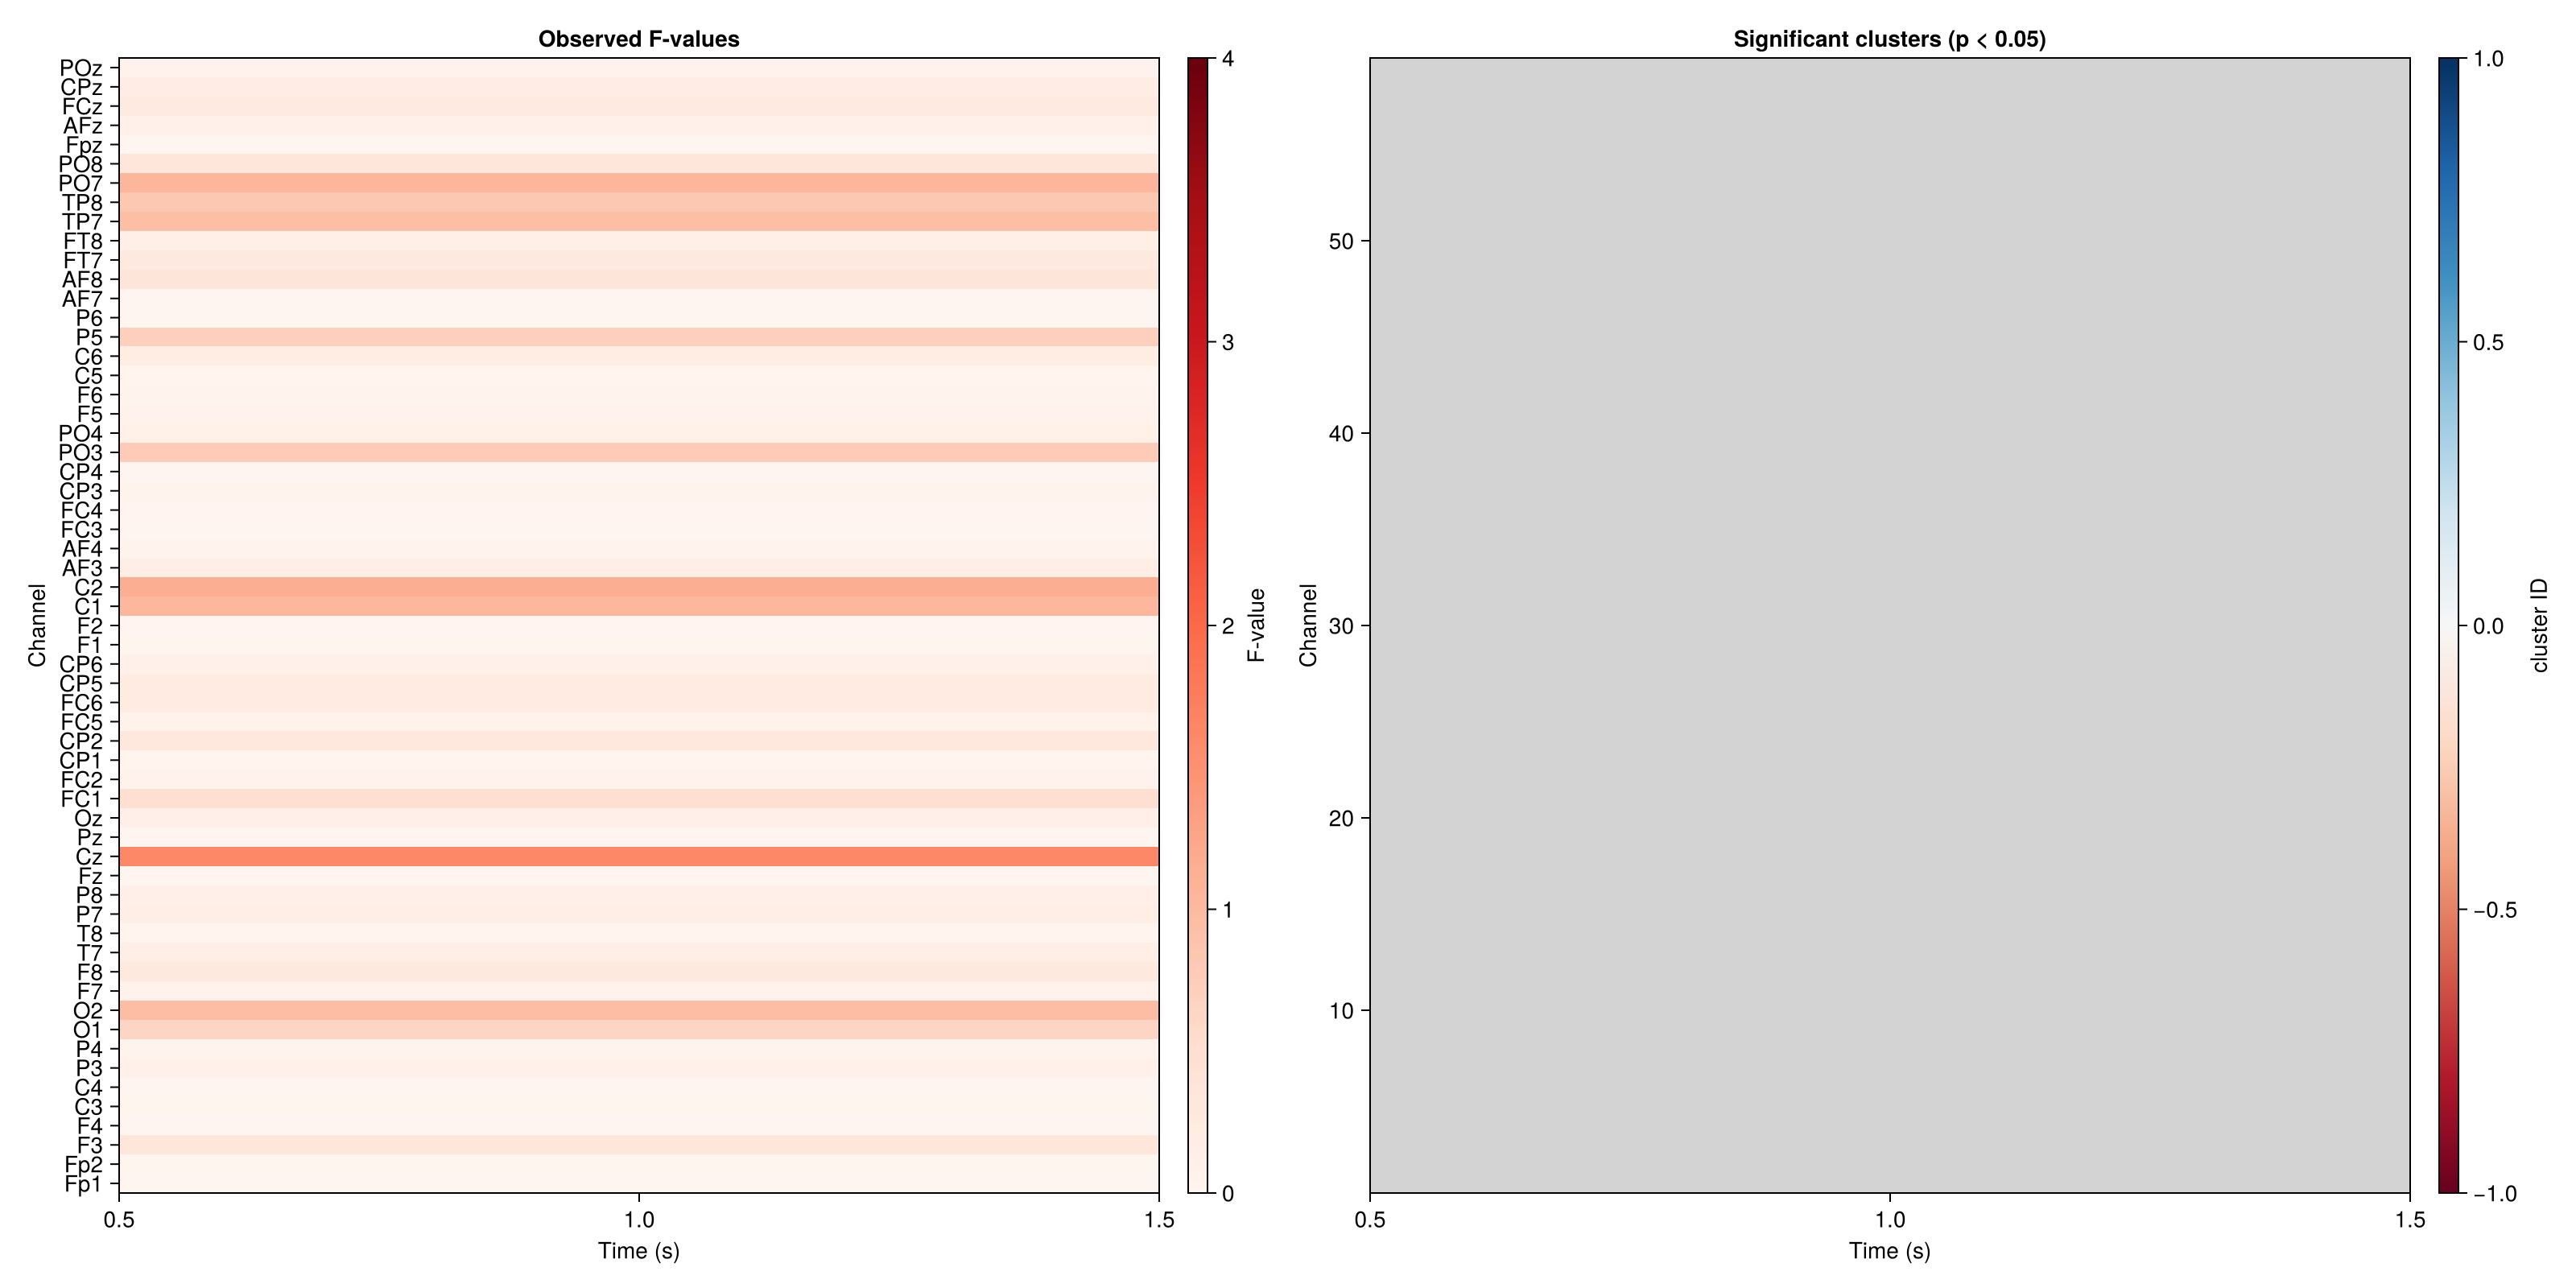

In [79]:
n_clusters = maximum(abs.(cluster_ids))
crange = n_clusters == 0 ? (-1.0, 1.0) : (-Float64(n_clusters), Float64(n_clusters))

# 4. Visualize
fig = Figure(size = (1600, 800))

n_ch_coef = nrow(df_result)
F_mat = reshape(df_result.F, 1, n_ch_coef)
F_mat = replace(F_mat, NaN=>0.0)

# Panel 1: Observed z-values with threshold contours
ax1 = Axis(fig[1, 1],
           title = "Observed F-values",
           xlabel = "Time (s)",
           ylabel = "Channel",
           yticks = (1:n_channels, electrode_labels))
hm1 = heatmap!(ax1, F_mat, colormap = :Reds, colorrange = (0, 4))
Colorbar(fig[1, 2], hm1, label = "F-value")

#contour!(ax1, F_mat, levels = [threshold],  color = (:red,  0.7), linewidth = 1.5)
#contour!(ax1, F_mat, levels = [-threshold], color = (:blue, 0.7), linewidth = 1.5)

# Panel 2: Significant cluster labels only (warm = positive, cool = negative, gray = non-sig / no cluster)
ax2 = Axis(fig[1, 3], title = "Significant clusters (p < 0.05)",
           xlabel = "Time (s)", ylabel = "Channel")
hm2 = heatmap!(ax2, cluster_display',
               colormap = :RdBu, colorrange = crange, nan_color = :lightgray)
Colorbar(fig[1, 4], hm2, label = "cluster ID")

fig

## 4. Plotting

In [80]:
# calculate electrode positions for topoplots
n = size(adjacency, 1)
coords = Dict(row.ch_name => (row.x, row.y) for row in eachrow(positions_df))

xs = [get(coords, electrode_labels[i], (0.0, 0.0))[1] for i in 1:n]
ys = [get(coords, electrode_labels[i], (0.0, 0.0))[2] for i in 1:n]

pos2d = [Point2f(xs[i], ys[i]) for i in 1:n]

59-element Vector{Point{2, Float32}}:
 [0.31910187, 0.9022613]
 [0.60451525, 0.9022613]
 [0.26805818, 0.70231706]
 [0.6555589, 0.70231706]
 [0.23090428, 0.4630553]
 [0.69271284, 0.4630553]
 [0.26805818, 0.22379355]
 [0.6555589, 0.22379355]
 [0.31910187, 0.023849286]
 [0.60451525, 0.023849286]
 ⋮
 [0.022602523, 0.32034862]
 [0.90101457, 0.32034862]
 [0.19036429, 0.08944435]
 [0.7332528, 0.08944435]
 [0.46180853, 0.9248639]
 [0.46180853, 0.7760589]
 [0.46180853, 0.57594186]
 [0.46180853, 0.35016876]
 [0.46180853, 0.11926448]

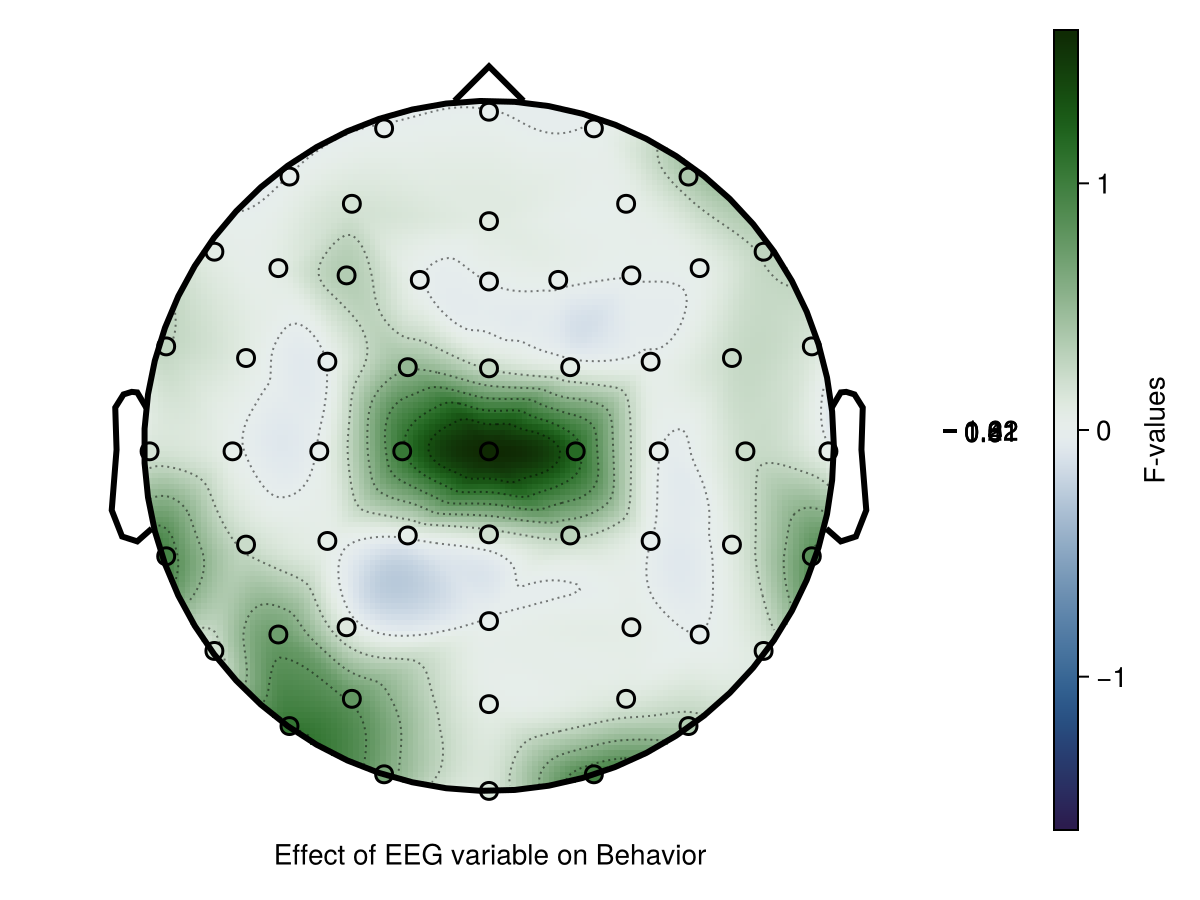

In [81]:
# create topoplot

#pos3d = hart.electrodes["pos"][channel_idx, :]  # 32x3 matrix for selected channels
#pos2d = [Point2f(pos3d[i,1], pos3d[i,2]) for i in 1:size(pos3d,1)]  # convert to 2D points for topoplot
sig_mask = pvals_clustermass .< 0.05

cluster_data = copy(z_vals)
plot_data = reshape(cluster_data, size(cluster_data)..., 1)  # reshape for plotting (or use df)

min_val, max_val = extrema(plot_data)
limit = max(abs(min_val), abs(max_val))  # get the limits

#cluster_data[.!sig_mask] .= 0.0  # Set non-significant to zero (or NaN)
# Ensure correct orientation: time x channels
df = DataFrame(
    :estimate => vec(cluster_data),  # no transpose, time is slow axis, channels is fast axis
    :channel => repeat(1:size(cluster_data, 1), outer = size(cluster_data, 2)),
    :time => repeat(1:size(cluster_data, 2), inner = size(cluster_data, 1))
)

# Highlight significant channels: a channel is significant if any time point is significant for it
sig_ch = [any(sig_mask[ch, :]) for ch in 1:n_channels]

marker_colors = [is_sig ? :yellow : :black for is_sig in sig_ch] # Set marker color: orange for significant, black for others
strokes = [is_sig ? 3 : 1.5 for is_sig in sig_ch]
sizes = fill(12, 59)

fig = Figure()

plot_topoplot!(
    fig[1, 1],
    plot_data[:, 1, 1];  # df
    positions = pos2d,
    #mapping=(; y=:estimate),
    axis = (; xlabel = "Effect of EEG variable on Behavior"),
    visual = (; colormap = :cork, contours = true, colorrange = (-limit, limit)),  # this is a hack
    #colorbar = (; limits = (-2.3, 2.3)),
    #colorbar = (; colorrange = (-2.3, 2.3)),
    #colorbar = (; height = 150, label = "z-values"), #, limits = (-4.5, 4.5)),
    colorbar = (;  label = "", width=1, height=1), # height
    topo_attributes = (;
        label_scatter = (;
            markersize = sizes,
            strokecolor = marker_colors,
            strokewidth = strokes)),
    )

Colorbar(fig[1, 2], colorrange = (-limit, limit), colormap = :cork, label = "F-values", height = 400)  # hack because colorbar does not match what I specify
#fig.colorrange = (-2.3, 2.3)
fig


In [82]:
min_val, max_val = extrema(plot_data)
limit = max(abs(min_val), abs(max_val))
colorrange = (-limit, limit)

(-4.431734551106316, 4.431734551106316)